In [32]:
import lgdo
import lh5
import numpy as np
import awkward as ak
import os
import re

In [33]:
filepath = "/mnt/atlas02/users/leoli/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "00"
run_cal = "037"

pnum_phy_bg = "00"
run_phy_bg = "038"

pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1', 's700ns_mw3', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
    's1000ns_mw1',  's1000ns_mw3',  's1000ns_mw5',  's1000ns_mw7','s1000ns_mw15',
    's2000ns_mw3',  's2000ns_mw5',  's2000ns_mw7',
]

def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)
        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")

        missing_this_run = []

        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")

        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "interval": f"{m.group(1)}ns",
            "mw": f"mw{m.group(2)}",

            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,

            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,

            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )

    return db
run_db = build_run_db(runs, filepath)

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pygama.pargen.energy_cal as pgc
import pygama.pargen.survival_fractions as sf

In [35]:
FIT_CONFIGS = {
    "dep": {
        "range": (1565.0, 1615.0),
        "peak": 1592.5,
        "func": sf.gauss_on_step,
    },
    "sep": {
        "range": (2070.0, 2140.0),
        "peak": 2103.5,
        "func": sf.hpge_peak,
    },
    "fep": {
        "range": (2580.0, 2645.0),
        "peak": 2614.5,
        "func": sf.hpge_peak,
    },
}

In [36]:
run_1 = "s60ns_mw3"
run_2 = "s300ns_mw5"

In [37]:
pathlist = "phy_signal_pathlist"

In [38]:
E_1=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run_1][pathlist])
A_max_mw_o_E_Classifier_1=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run_1][pathlist])
Iasy_std = lh5.read("ch002/hit/Iasy",run_db['s100ns_mw5'][pathlist])
is_valid_waveform_1= lh5.read("ch002/hit/is_valid_waveform",run_db[run_1][pathlist])
low_cut_1 = lh5.read("ch002/hit/A_max_mw_o_E_fix_Low_Cut",run_db[run_1][pathlist])

In [39]:
E_1 = np.asarray(E_1)
# A_max_mw_o_E_High_Side_Cut_std = np.asarray(A_max_mw_o_E_High_Side_Cut_std)
Iasy_std = np.asarray(Iasy_std)
A_max_mw_o_E_Classifier_1= np.asarray(A_max_mw_o_E_Classifier_1)
is_valid_waveform_1 = np.asarray(is_valid_waveform_1)
low_cut_1 = np.asarray(low_cut_1)

In [40]:
E_2=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run_2][pathlist])
A_max_mw_o_E_Classifier_2=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run_2][pathlist])
is_valid_waveform_2= lh5.read("ch002/hit/is_valid_waveform",run_db[run_2][pathlist])
low_cut_2 = lh5.read("ch002/hit/A_max_mw_o_E_fix_Low_Cut",run_db[run_2][pathlist])

In [41]:
E_2 = np.asarray(E_2)
A_max_mw_o_E_Classifier_2= np.asarray(A_max_mw_o_E_Classifier_2)
is_valid_waveform_2 = np.asarray(is_valid_waveform_2)
low_cut_2 = np.asarray(low_cut_2)   

In [42]:
import pickle 
with open("/mnt/atlas02/users/leoli/AoverE_analysis/both_sided_cuts/survival_db_from_dataprod.pkl", "rb") as f:
    survival_db = pickle.load(f)

In [43]:
ROI_mask = (E_1 > 1839) & (E_1 < 2239)
cut_value_1 = survival_db[run_1]['cut_value_90']
cut_value_2 = survival_db[run_2]['cut_value_90']

In [44]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [58]:
# Check that all arrays correspond to the same events
assert (
    A_max_mw_o_E_Classifier_1.shape
    == A_max_mw_o_E_Classifier_2.shape
    == ROI_mask.shape
    == low_cut_1.shape
    == low_cut_2.shape
), (
    f"Shape mismatch: "
    f"A_max_mw_o_E_Classifier_1={A_max_mw_o_E_Classifier_1.shape}, "
    f"A_max_mw_o_E_Classifier_2={A_max_mw_o_E_Classifier_2.shape}, "
    f"ROI_mask={ROI_mask.shape}, "
    f"low_cut_1={low_cut_1.shape}, "
    f"low_cut_2={low_cut_2.shape}"
)

# DEP selection plus finite classifier values
selection = (
    ROI_mask
    & np.isfinite(A_max_mw_o_E_Classifier_1)
    & np.isfinite(A_max_mw_o_E_Classifier_2)
)

# Selected classifier values
x = A_max_mw_o_E_Classifier_1[selection]
y = A_max_mw_o_E_Classifier_2[selection]

# Selected Boolean cut decisions
pass_1 = low_cut_1[selection]
pass_2 = low_cut_2[selection]

print(f"Selected ROI events: {len(x):,}")

Selected ROI events: 76,639


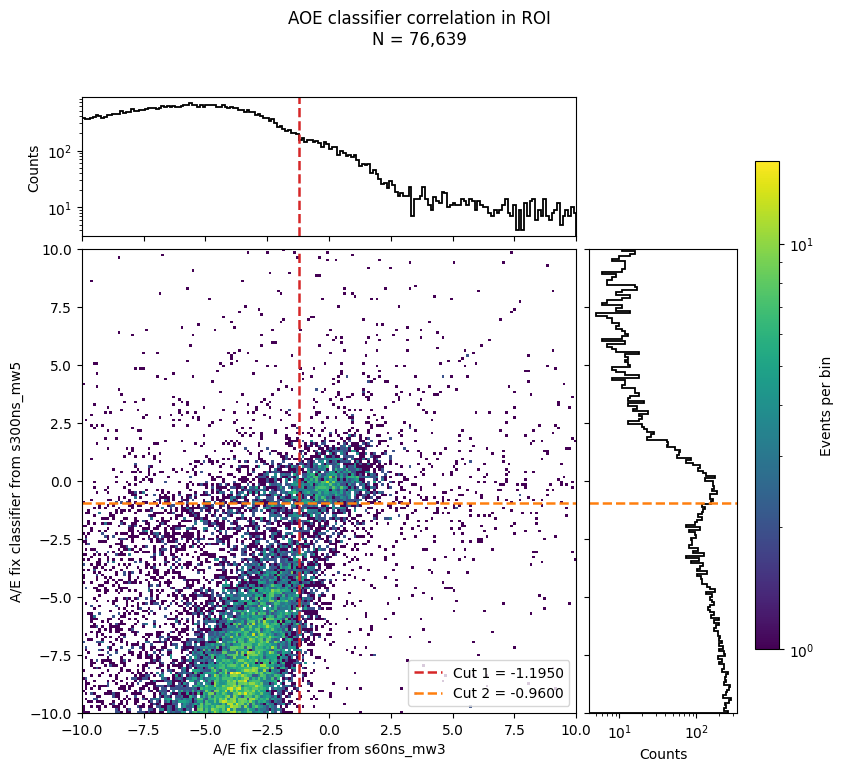

In [59]:
# Remove extreme outliers from the displayed range only.
# The underlying Boolean statistics still use all selected DEP events.
# x_range = tuple(np.percentile(x, [0.2, 99.8]))
# y_range = tuple(np.percentile(y, [0.2, 99.8]))
x_range = [-10,10]
y_range = [-10,10]
fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)

# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in ROI\n"
    f"N = {len(x):,}",
    y=0.99,
)

plt.show()

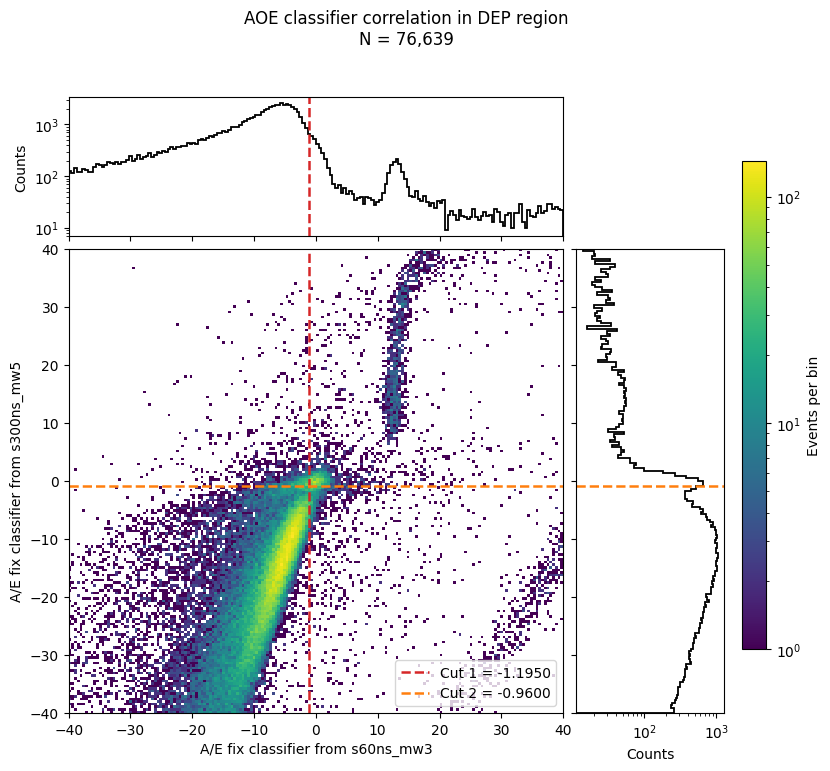

In [56]:
# Remove extreme outliers from the displayed range only.
# The underlying Boolean statistics still use all selected DEP events.
# x_range = tuple(np.percentile(x, [0.2, 99.8]))
x_range = [-40,40]
y_range = [-40,40]

fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)

# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in DEP region\n"
    f"N = {len(x):,}",
    y=0.99,
)

plt.show()

In [48]:
# Four possible cut outcomes
pass_both = pass_1 & pass_2
only_cut_2_rejects = pass_1 & ~pass_2
only_cut_1_rejects = ~pass_1 & pass_2
reject_both = ~pass_1 & ~pass_2

categories = {
    "Pass both": pass_both,
    "Rejected only by cut 2": only_cut_2_rejects,
    "Rejected only by cut 1": only_cut_1_rejects,
    "Rejected by both": reject_both,
}

for name, category_mask in categories.items():
    print(
        f"{name:27s}: "
        f"{category_mask.sum():8,d} "
        f"({category_mask.mean():7.2%})"
    )

Pass both                  :    4,936 (  6.44%)
Rejected only by cut 2     :    3,195 (  4.17%)
Rejected only by cut 1     :    1,273 (  1.66%)
Rejected by both           :   67,235 ( 87.73%)


In [49]:
rng = np.random.default_rng(42)


def subsample(mask, maximum=5000):
    indices = np.flatnonzero(mask)

    if len(indices) > maximum:
        indices = rng.choice(
            indices,
            size=maximum,
            replace=False,
        )

    return indices


indices_cut_2_only = subsample(
    only_cut_2_rejects,
)

indices_cut_1_only = subsample(
    only_cut_1_rejects,
)

ax_main.scatter(
    x[indices_cut_2_only],
    y[indices_cut_2_only],
    s=9,
    alpha=0.55,
    color="tab:orange",
    edgecolors="none",
    label=(
        "Rejected only by cut 2 "
        f"({only_cut_2_rejects.mean():.2%})"
    ),
)

ax_main.scatter(
    x[indices_cut_1_only],
    y[indices_cut_1_only],
    s=9,
    alpha=0.55,
    color="tab:cyan",
    edgecolors="none",
    label=(
        "Rejected only by cut 1 "
        f"({only_cut_1_rejects.mean():.2%})"
    ),
)

ax_main.legend(
    loc="best",
    fontsize=9,
)


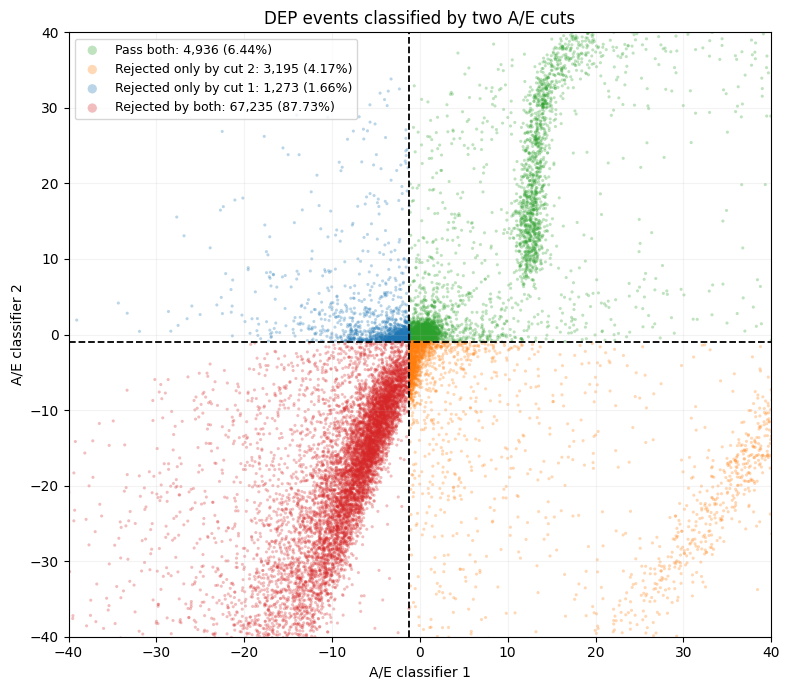

In [50]:
category_info = [
    (
        "Pass both",
        pass_both,
        "tab:green",
    ),
    (
        "Rejected only by cut 2",
        only_cut_2_rejects,
        "tab:orange",
    ),
    (
        "Rejected only by cut 1",
        only_cut_1_rejects,
        "tab:blue",
    ),
    (
        "Rejected by both",
        reject_both,
        "tab:red",
    ),
]

fig, ax = plt.subplots(figsize=(8, 7))

for label, category_mask, color in category_info:
    indices = subsample(
        category_mask,
        maximum=10_000,
    )

    ax.scatter(
        x[indices],
        y[indices],
        s=5,
        alpha=0.30,
        color=color,
        edgecolors="none",
        label=(
            f"{label}: "
            f"{category_mask.sum():,} "
            f"({category_mask.mean():.2%})"
        ),
    )

ax.axvline(
    cut_value_1,
    color="black",
    linestyle="--",
    linewidth=1.3,
)

ax.axhline(
    cut_value_2,
    color="black",
    linestyle="--",
    linewidth=1.3,
)

ax.set_xlim(x_range)
ax.set_ylim(y_range)

ax.set_xlabel("A/E classifier 1")
ax.set_ylabel("A/E classifier 2")
ax.set_title("DEP events classified by two A/E cuts")

ax.legend(
    fontsize=9,
    markerscale=3,
)

ax.grid(alpha=0.15)

fig.tight_layout()
plt.show()

In [51]:
rejected_1 = ~pass_1
rejected_2 = ~pass_2

rejection_union = rejected_1 | rejected_2
rejection_intersection = rejected_1 & rejected_2

jaccard = (
    rejection_intersection.sum()
    / rejection_union.sum()
    if rejection_union.any()
    else np.nan
)

print()
print(f"Cut 1 pass fraction:  {pass_1.mean():.3%}")
print(f"Cut 2 pass fraction:  {pass_2.mean():.3%}")
print(f"Pass both:             {(pass_1 & pass_2).mean():.3%}")
print(f"Decision agreement:    {(pass_1 == pass_2).mean():.3%}")
print(f"Classifier correlation: {np.corrcoef(x, y)[0, 1]:.4f}")
print(f"Rejection Jaccard index: {jaccard:.4f}")


Cut 1 pass fraction:  10.609%
Cut 2 pass fraction:  8.102%
Pass both:             6.441%
Decision agreement:    94.170%
Classifier correlation: 0.4897
Rejection Jaccard index: 0.9377


In [52]:
print(
    "Cut 1 Boolean/threshold agreement:",
    np.mean(pass_1 == (x > cut_value_1)),
)

print(
    "Cut 2 Boolean/threshold agreement:",
    np.mean(pass_2 == (y > cut_value_2)),
)

Cut 1 Boolean/threshold agreement: 1.0
Cut 2 Boolean/threshold agreement: 1.0
